**# Heart Disease Prediction using Machine Learning

The goal of this project is to predict whether a patient has heart disease using machine learning algorithms.

Three models were trained and compared to identify the best-performing model.**

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Data Preprocessing

The dataset was loaded and inspected for structure, missing values, and feature types.

The target variable is 'target', which indicates whether a patient has heart disease.

The dataset was split into training and testing sets using an 80:20 ratio.

Feature scaling was applied using StandardScaler to improve the performance of distance-based algorithms such as KNN and Logistic Regression.

In [4]:
df = pd.read_csv("heart.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611

In [6]:
df['target'].value_counts()

,count
target,
1,526
0,499


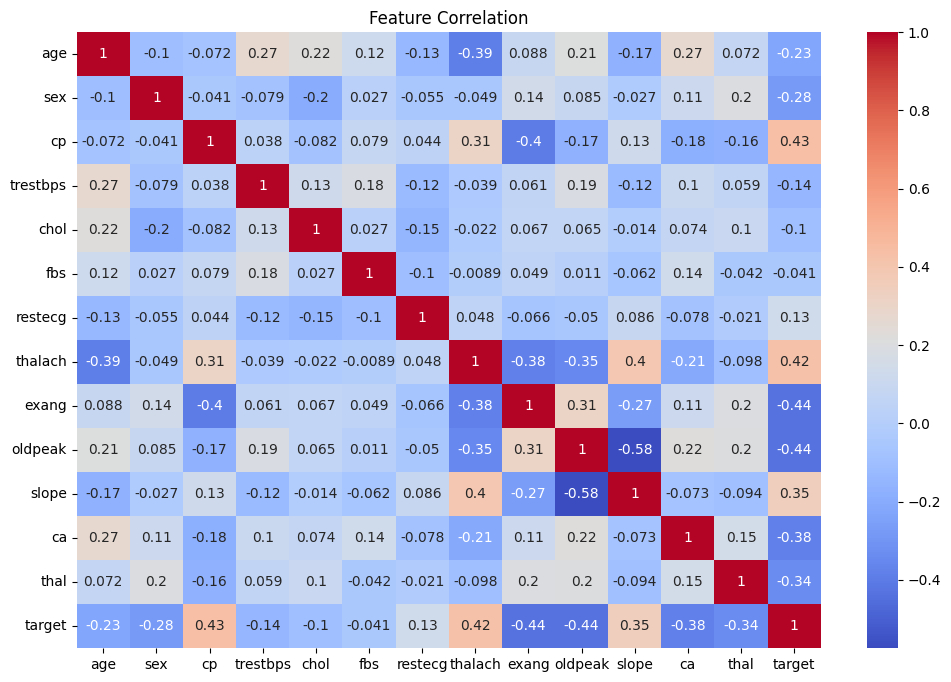

In [7]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

## Feature Engineering

Feature importance analysis was performed using Random Forest.

The analysis helps identify which variables contribute most to heart disease prediction.

Features with higher importance have a stronger influence on the model's decision-making process.

In [8]:
X = df.drop('target', axis=1)
y = df['target']

## Model Training

Three machine learning algorithms were selected for comparison:

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Random Forest

These models represent different approaches to classification and allow performance comparison.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False,
    inplace=True
)

print(importance)

     Feature  Importance
2         cp    0.135072
11        ca    0.127327
7    thalach    0.122169
9    oldpeak    0.121905
12      thal    0.110518
0        age    0.077908
4       chol    0.074822
3   trestbps    0.071171
8      exang    0.057594
10     slope    0.045782
1        sex    0.028731
6    restecg    0.018557
5        fbs    0.008444


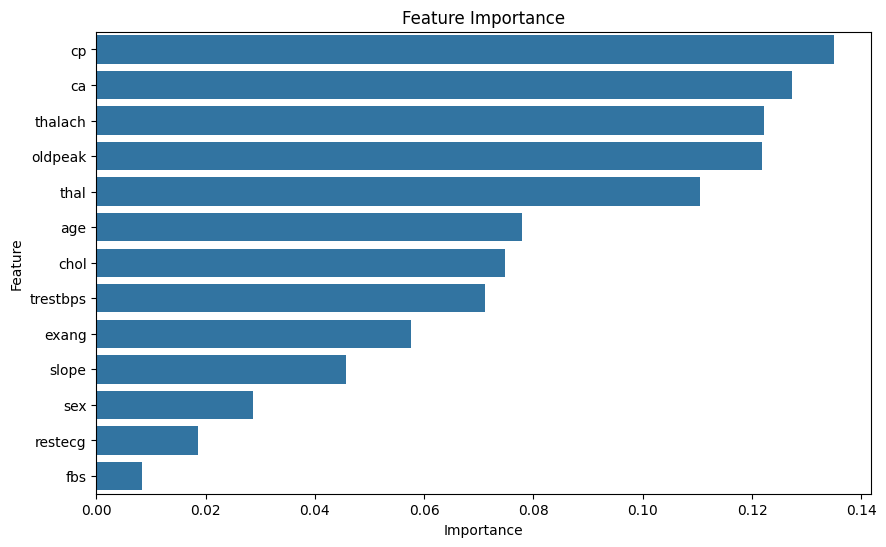

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance")
plt.show()

In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

## Model Comparison

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

The comparison table allows objective evaluation of each model's performance.

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [17]:
lr_acc = accuracy_score(y_test, lr_pred)
lr_pre = precision_score(y_test, lr_pred)
lr_rec = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

In [18]:
knn_acc = accuracy_score(y_test, knn_pred)
knn_pre = precision_score(y_test, knn_pred)
knn_rec = recall_score(y_test, knn_pred)
knn_f1 = f1_score(y_test, knn_pred)

In [19]:
rf_acc = accuracy_score(y_test, rf_pred)
rf_pre = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

In [20]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy":[
        lr_acc,
        knn_acc,
        rf_acc
    ],
    "Precision":[
        lr_pre,
        knn_pre,
        rf_pre
    ],
    "Recall":[
        lr_rec,
        knn_rec,
        rf_rec
    ],
    "F1 Score":[
        lr_f1,
        knn_f1,
        rf_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.795122,0.756303,0.873786,0.810811
1,KNN,0.834146,0.800000,0.893204,0.844037
2,Random Forest,0.985366,1.000000,0.970874,0.985222


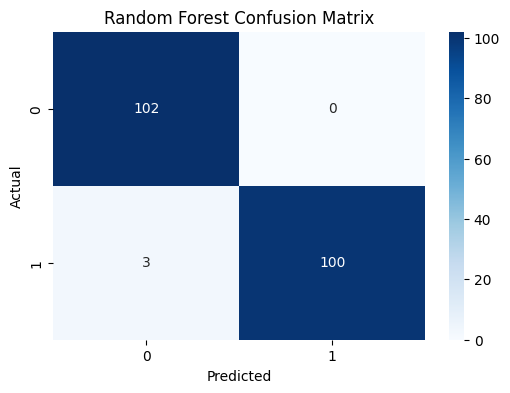

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Best Model Analysis

Random Forest achieved the best overall performance among the evaluated models.

The confusion matrix shows that the model correctly classified most patients with relatively few misclassifications.

Its ensemble learning approach helps capture complex relationships in the data and reduces overfitting.

# Conclusion

1. Three machine learning algorithms were trained and evaluated on the Heart Disease dataset.

2. Random Forest achieved the highest overall performance based on evaluation metrics.

3. Feature importance analysis identified key predictors of heart disease.

4. The confusion matrix demonstrated strong classification performance with relatively few errors.

5. Therefore, Random Forest is the most suitable model for predicting heart disease in this dataset.